In [1]:
root = "/content/drive/MyDrive/Colab/"
data_root = root + "Gan/lfw_funneled"

In [2]:
import os
import glob
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
import matplotlib.pyplot as plt
from IPython.display import clear_output


In [3]:
image_size = (64, 64)
codings_size = 100
batch_size = 32
n_epochs = 50

In [4]:
image_paths = glob.glob(os.path.join(data_root, '**', '*.jpg'), recursive=True)

x_train = []
for path in image_paths:
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize(image_size)
        arr = (np.asarray(img) / 127.5) - 1.0
        x_train.append(arr)
    except Exception as e:
        print(f"Could not process {path}: {e}")

x_train = np.array(x_train, dtype=np.float32)

In [5]:
x_train.shape, x_train[0]

((1323, 64, 64, 3),
 array([[[ 0.85882354,  0.7019608 ,  0.52156866],
         [ 0.8745098 ,  0.70980394,  0.5294118 ],
         [ 0.8509804 ,  0.6862745 ,  0.49803922],
         ...,
         [-0.9607843 , -0.9607843 , -0.9607843 ],
         [-0.96862745, -0.96862745, -0.96862745],
         [-0.9843137 , -0.9843137 , -0.9843137 ]],
 
        [[ 0.85882354,  0.7254902 ,  0.5921569 ],
         [ 0.85882354,  0.7254902 ,  0.5921569 ],
         [ 0.8509804 ,  0.70980394,  0.5686275 ],
         ...,
         [-0.9529412 , -0.9529412 , -0.9529412 ],
         [-0.9529412 , -0.9529412 , -0.9529412 ],
         [-0.99215686, -0.99215686, -0.99215686]],
 
        [[ 0.8980392 ,  0.75686276,  0.64705884],
         [ 0.8901961 ,  0.7490196 ,  0.6392157 ],
         [ 0.8666667 ,  0.7254902 ,  0.6156863 ],
         ...,
         [-0.96862745, -0.96862745, -0.96862745],
         [-0.9843137 , -0.9843137 , -0.9843137 ],
         [-0.99215686, -0.99215686, -0.99215686]],
 
        ...,
 
        [[-0.4

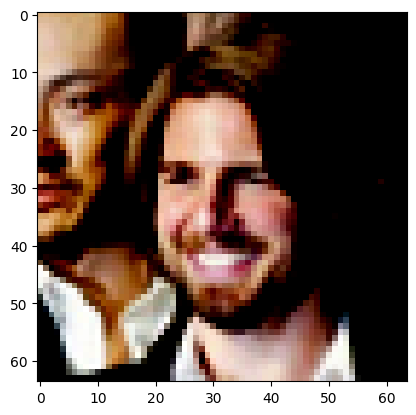

In [6]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
import numpy as np
import pandas as pd

In [8]:
generator = Sequential([
    Dense(8 * 8 * 512, input_shape=[codings_size]),
    Reshape([8, 8, 512]),
    BatchNormalization(),
    LeakyReLU(0.2),
    Conv2DTranspose(256, kernel_size=5, strides=2, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2DTranspose(128, kernel_size=5, strides=2, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2DTranspose(3, kernel_size=5, strides=1, padding='same', activation='tanh'),
])

# --- Build Discriminator ---
discriminator = Sequential([
    # input: 64x64x3
    Conv2D(64, kernel_size=5, strides=2, padding='same', input_shape=[64, 64, 3]),
    LeakyReLU(0.2),
    Dropout(0.4),
    Conv2D(128, kernel_size=5, strides=2, padding='same'),
    LeakyReLU(0.2),
    Dropout(0.4),
    Conv2D(256, kernel_size=5, strides=2, padding='same'),
    LeakyReLU(0.2),
    Dropout(0.4),
    Conv2D(512, kernel_size=5, strides=2, padding='same'),
    LeakyReLU(0.2),
    Dropout(0.4),
    Flatten(),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
gan = Sequential([generator, discriminator])

d_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.002)
g_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)

discriminator.compile(loss='binary_crossentropy', optimizer=d_optimizer)
discriminator.trainable = False
gan.compile(loss='binary_crossentropy', optimizer=g_optimizer)

In [14]:
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(1000).batch(batch_size, drop_remainder=True).prefetch(1)

In [26]:
def train_gan(gan, dataset, batch_size, codings_size, n_epochs):
    generator, discriminator = gan.layers
    for epoch in range(1, n_epochs + 1):
        print(f"Epoch {epoch}/{n_epochs}")
        for X_batch in dataset:
            # Train discriminator
            noise = tf.random.normal([batch_size, codings_size])
            generated = generator(noise)
            X_fake_real = tf.concat([generated, X_batch], axis=0)
            y_disc = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
            discriminator.trainable = True
            d_loss = discriminator.train_on_batch(X_fake_real, y_disc)
            discriminator.trainable = False

            noise = tf.random.normal([batch_size, codings_size])
            y_gen = tf.constant([[1.]] * batch_size)
            g_loss = gan.train_on_batch(noise, y_gen)

        noise = tf.random.normal([4, codings_size])
        gen_imgs = generator(noise, training=False).numpy()
        plt.figure(figsize=(8, 2))
        for i in range(4):
            plt.subplot(1, 4, i + 1)
            plt.imshow((gen_imgs[i] + 1) / 2)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

In [30]:
gan.save(os.path.join(root, "Gan/gan_color_64.keras"))

Epoch 1/150


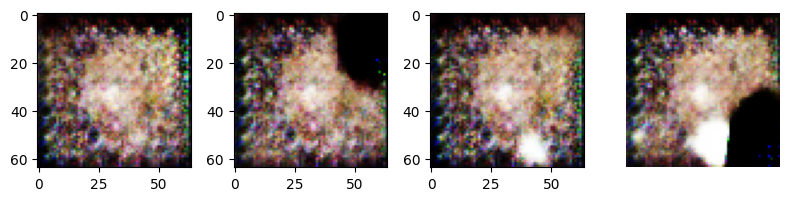

Epoch 2/150


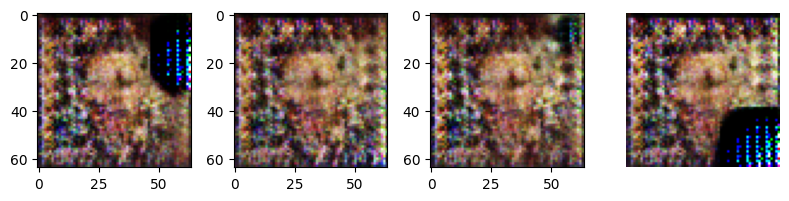

Epoch 3/150


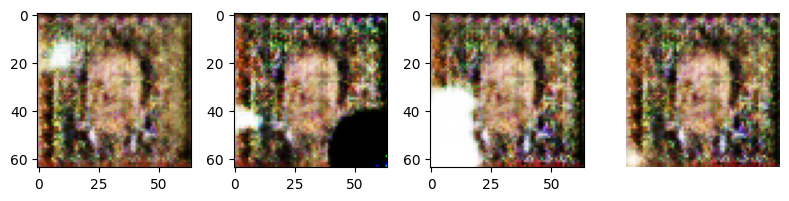

Epoch 4/150


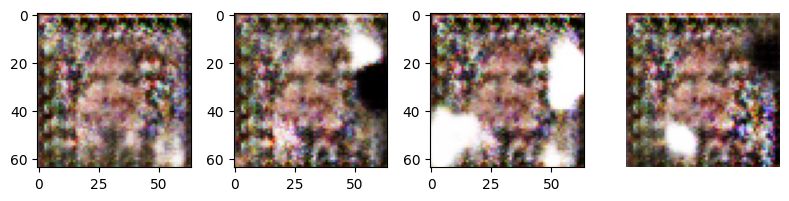

Epoch 5/150


KeyboardInterrupt: 

In [31]:
train_gan(gan, dataset, batch_size, codings_size, 150)